Датасет `bio.csv` містить дані про біоконцентрацію хімічних сполук. Ознаками є молекулярні дескриптори. Цільовою змінною є `logBCF`.

Датасет `bio_predict.csv` не містить значень цільової змінної і призначений для зовнішнього оцінювання.

In [1]:
import sklearn
import xgboost
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import ipywidgets as widgets
import seaborn as sns
sns.set_style("whitegrid")
import warnings
warnings.filterwarnings("ignore")

## Завдання 1

[3 бали] 


Імпортувати датасет `bio.csv` у об'єкт `DataFrame` і провести попередній аналіз даних засобами `pandas`, `matplotlib`, `seaborn`.  

In [2]:
DataFrame = pd.read_csv("bio.csv")
DataFrame 

,nHM,piPC09,PCD,X2Av,MLOGP,ON1V,N-072,B02[C-N],F04[C-O],logBCF
0,0,0.0,1.49,0.14,1.35,0.72,0,1,5,0.74
1,0,0.0,1.47,0.14,1.70,0.88,0,1,5,0.93
2,0,0.0,1.20,0.25,4.14,2.06,0,0,0,3.24
3,0,0.0,1.69,0.13,1.89,0.79,0,1,8,-0.40
4,0,0.0,0.52,0.25,2.65,1.31,0,0,0,2.24
...,...,...,...,...,...,...,...,...,...,...
674,3,0.0,1.25,0.21,3.62,0.77,0,0,1,2.84
675,3,0.0,1.25,0.23,4.06,0.62,0,0,0,2.89
676,2,0.0,1.25,0.20,2.73,0.64,0,0,1,1.17
677,6,0.0,0.65,0.32,3.66,0.40,0,0,0,3.82


In [3]:
DataFrame.shape

(679, 10)

In [4]:
DataFrame.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 679 entries, 0 to 678
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   nHM       679 non-null    int64  
 1   piPC09    679 non-null    float64
 2   PCD       679 non-null    float64
 3   X2Av      679 non-null    float64
 4   MLOGP     679 non-null    float64
 5   ON1V      679 non-null    float64
 6   N-072     679 non-null    int64  
 7   B02[C-N]  679 non-null    int64  
 8   F04[C-O]  679 non-null    int64  
 9   logBCF    679 non-null    float64
dtypes: float64(6), int64(4)
memory usage: 53.2 KB


Отже, маємо 679 non-null об'єктів, 9 числових ознак і цільову змінну logBCF. Подивимось на опис кожної ознаки.

In [5]:
#Зауваження: Для роботи віджету поле потрібно перезапустити (не загрузиться автоматично при відкритті файлу)
def get_describe(column):
    return DataFrame[column].describe()
widgets.interact(get_describe, column=widgets.Dropdown(options=DataFrame.columns, description="Column:"))

interactive(children=(Dropdown(description='Column:', options=('nHM', 'piPC09', 'PCD', 'X2Av', 'MLOGP', 'ON1V'…

<function __main__.get_describe(column)>

#### Цільова змінна

Розподіл значень цільової змінної і її box-plot.

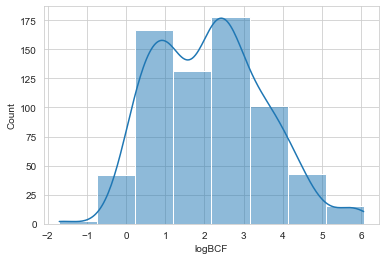

In [6]:
sns.histplot(data = DataFrame, x = "logBCF", kde=True, bins=8, palette="YlGnBu")
plt.show()

<AxesSubplot:xlabel='logBCF'>

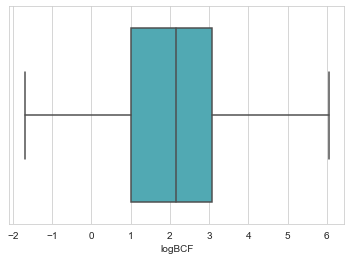

In [7]:
sns.boxplot(x=DataFrame["logBCF"], palette="YlGnBu")

Бачимо, що розподіл близький до симетричного, а аномальних значень на boxplot немає.

Подивимось як би виглядали аналогічні графіки на непрологарифмованій цільовій змінній.

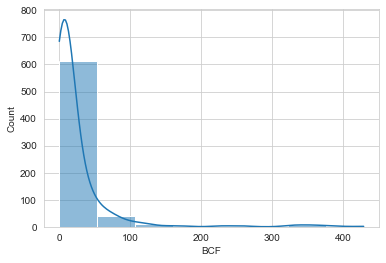

In [8]:
DataFrame["BCF"] = DataFrame["logBCF"].map(lambda x: math.e ** x)
sns.histplot(data = DataFrame, x = "BCF", kde=True, bins=8, palette="YlGnBu")
plt.show()

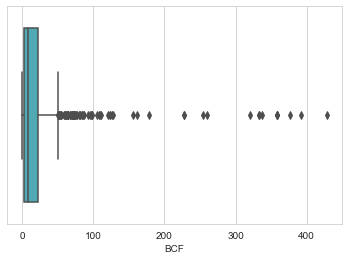

In [9]:
sns.boxplot(x=DataFrame["BCF"], palette="YlGnBu")
DataFrame = DataFrame.drop(columns=["BCF"])

Бачимо, що логарифмування допомагає зробити цільову змінну 'зручнішою'

Побудуємо також графіки розподілів інших ознак

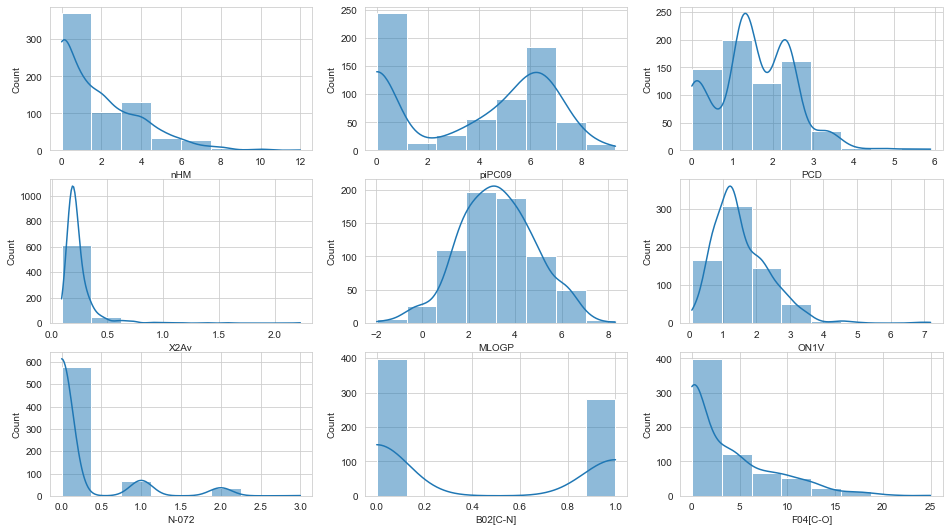

In [10]:
fig, ax = plt.subplots(nrows=3, ncols=3, figsize=(16,9))
for i,col in enumerate(DataFrame.columns[:-1]):
    sns.histplot(x=DataFrame[col],kde=True, bins = 8,  palette="YlGnBu", ax = ax[i // 3][i % 3])

#### Кореляції

Знайдемо ознаки найбільш лінійно пов'язані з цільовою змінною за допомогою коефіцієнту кореляції Пірсона

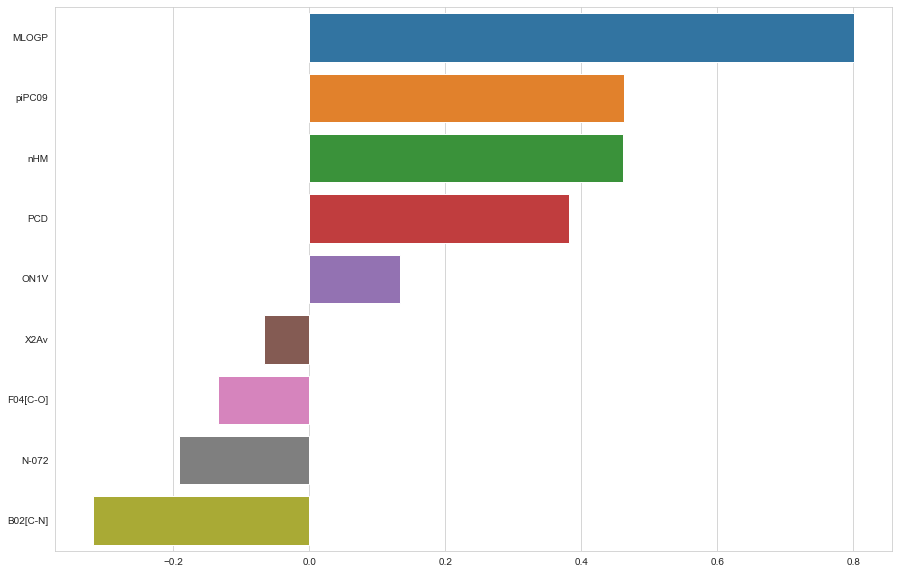

In [11]:
numeric_data = DataFrame.drop(columns=["logBCF"]).select_dtypes([np.number])
numeric_features = numeric_data.columns

correlations = DataFrame.drop(columns=["logBCF"])[numeric_features].corrwith(DataFrame["logBCF"]).sort_values(ascending=False)


plot = sns.barplot(y=correlations.index, x=correlations)
plot.figure.set_size_inches(15, 10)

Подивимось на графік цільової змінної від найбільш лінійно пов'язаної ознаки

<AxesSubplot:xlabel='MLOGP', ylabel='logBCF'>

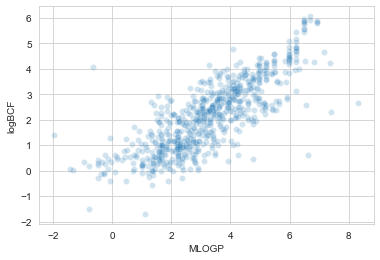

In [12]:
sns.scatterplot(x=DataFrame.drop(columns=["logBCF"])["MLOGP"], y=DataFrame["logBCF"], alpha = 0.2)

Бачимо, що залежність справді доволі близька до лінійної

Подивимось на кореляцію між іншими ознаками

<AxesSubplot:>

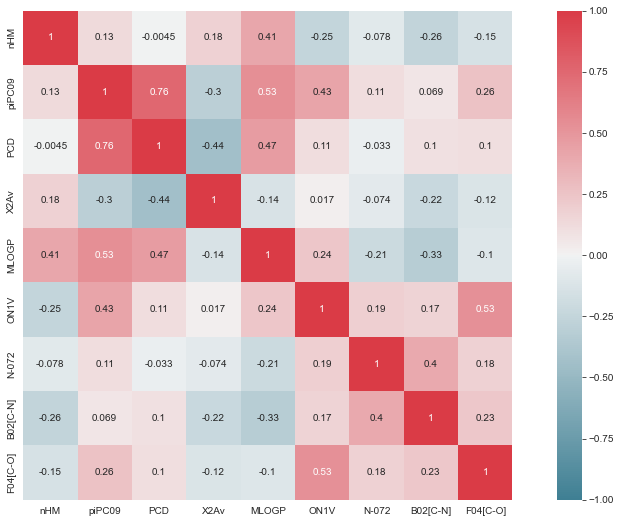

In [13]:
corr = DataFrame.drop(columns=["logBCF"]).corr()
fig, ax = plt.subplots(figsize=(16, 9))
sns.heatmap(corr, mask=np.zeros_like(corr, dtype=np.bool),vmin=-1, vmax=1,ax=ax,cmap=sns.diverging_palette(220, 10, as_cmap=True), square=True, annot=True)


#### Outliers Handling

На графіках нижче можна побачити, що багато ознак містять певні аномальні значення. Ці викиди можуть негативно впливати на результати наших моделей.

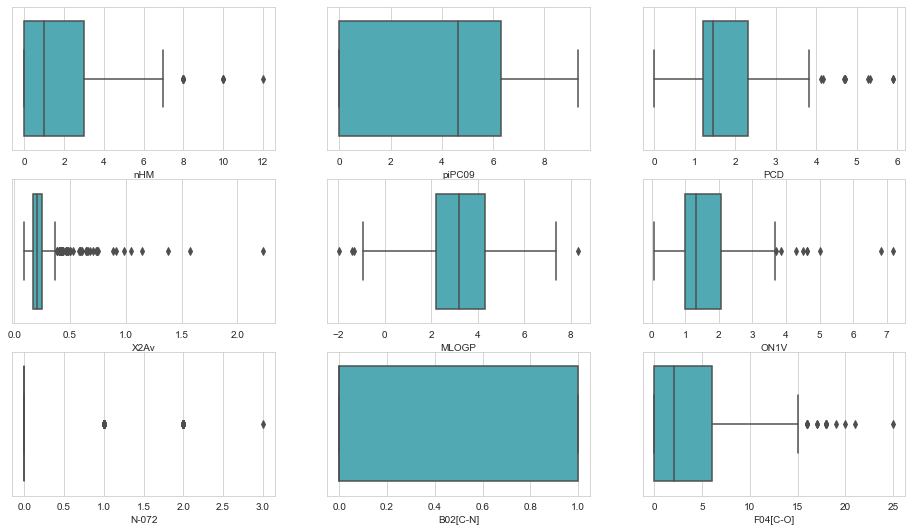

In [14]:
fig, ax = plt.subplots(nrows=3, ncols=3, figsize=(16,9))
for i,col in enumerate(DataFrame.columns[:-1]):
    sns.boxplot(x=DataFrame[col], palette="YlGnBu", ax = ax[i // 3][i % 3])

Спробуємо визначити об'єкти з аномальними значеннями числових ознак і видалити їх. Робити це будемо наступним чином:
* Напишемо функцію, яка в циклі буде проходити по кожній числовій ознаці і визначати викиди
* На кожній ітерації викидом вважатимемо те значення, яке `менше за 1-ий квантиль - крок викиду` або `більше за 3-ій квантиль + крок викиду`
* За крок викиду візьмемо 1,5 * IQR (Interquartile range)
* Для кожної ознаки записуватимемо індекси викидів в список. Після обробки всіх ознак видалятимемо ті рядки, поява яких в списку викидів перевищувала n разів

In [15]:
from collections import Counter
def outliers(df, features, n):
    outliers_ids = []
    for feature in features:
        q1 = np.percentile(df[feature], 25)
        q3 = np.percentile(df[feature], 75)
        step = 1.5*(q3 - q1)
        ids = df[(df[feature] < q1 - step) | (df[feature] > q3 + step)].index
        outliers_ids.extend(ids)
    outliers_ids = Counter(outliers_ids)
    delete = [key for key,value in outliers_ids.items() if value > n]
    return delete
delete = outliers(DataFrame, DataFrame.columns[:-1], 1)
delete

[111, 174, 320, 393, 458, 464, 507, 532, 91, 162, 312, 339, 215]

In [16]:
#DataFrame = DataFrame.drop(delete).reset_index(drop=True)

## Завдання 2

[9 балів]

### Задача регресії




   
   * Навчити модель `sklearn.ensemble.VotingRegressor` беручи у якості множини базових алгоритмів { `LinearRegression`, `SVR`, `KNeighborsRegressor`, `DecisionTreeRegressor` }  та експерементуючи з параметрами базових алгоритмів та композиції. Знайти коефіцієнт детермінації `R2` для найкращої моделі на відкладеній вибірці.
   
   
   * Навчити модель `sklearn.ensemble.BaggingRegressor` беручи у якості базових алгоритмів `DecisionTreeRegressor` та експерементуючи з параметрами композиції. Знайти коефіцієнт детермінації `R2` для найкращої моделі на відкладеній вибірці.
   
   
   * Навчити модель `sklearn.ensemble.AdaBoostRegressor` беручи у якості базових алгоритмів `DecisionTreeRegressor` та експерементуючи з параметрами композиції. Знайти коефіцієнт детермінації `R2` для найкращої моделі на відкладеній вибірці.
   
   
   * Навчити модель `sklearn.ensemble.GradientBoostingRegressor` беручи у якості базових алгоритмів `DecisionTreeRegressor` та експерементуючи з параметрами композиції. Знайти коефіцієнт детермінації `R2` для найкращої моделі на відкладеній вибірці.
   
   
   * Навчити модель `xgboost.XGBRegressor` беручи у якості базових алгоритмів `gbtree` або `gblinear` або `dart` (розглянути всі варіанти) та експерементуючи з параметрами композиції. Знайти коефіцієнт детермінації `R2` для найкращої моделі на відкладеній вибірці.
   
   
   * Навчити модель `sklearn.ensemble.StackingRegressor`, беручи у якості множини базових алгоритмів { `LinearRegression`, `SVR`, `KNeighborsRegressor`, `DecisionTreeRegressor` } а в якості `final_estimator` : `sklearn.linear_model.RidgeCV` та `sklearn.ensemble.RandomForestRegressor`(розглянути обидва варіанти) та експерементуючи з параметрами базових алгоритмів та композиції. Знайти коефіцієнт детермінації `R2` для найкращої моделі `StackingRegressor`.
   




Поділимо дані на навчальну та тестову вибірки

In [17]:
from sklearn.model_selection import train_test_split
def get_original():
    global X, y, X_train, X_test, y_train, y_test
    y = DataFrame["logBCF"]
    X = DataFrame.drop(columns=["logBCF"])
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=4)
get_original()

Напишемо потрібні функції для зручнішої роботи 

In [1]:
from sklearn.model_selection import GridSearchCV,RandomizedSearchCV
from sklearn.metrics import r2_score
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from itertools import permutations
from sklearn.model_selection import RepeatedKFold
from sklearn.model_selection import cross_validate
def get_best_params(pipeline):
    global X_train, X_test, y_train, y_test
    if  type(pipeline[1]) == sklearn.svm._classes.SVR:
        param_grid = {
            'regression__C' : np.logspace(-3, 2, 25),
            'regression__kernel' : ['linear','poly', "rbf", "sigmoid"],
        }
        searcher = GridSearchCV(pipeline, [param_grid],
                        scoring="neg_root_mean_squared_error", cv=5, n_jobs=-1)
        searcher.fit(X_train, y_train)
        best = {name[name.find("__") + 2:]: val for name, val in searcher.best_params_.items()}
        pipeline[1].set_params(**best)
    if  type(pipeline[1]) == sklearn.neighbors._regression.KNeighborsRegressor:
        param_grid = {
            'regression__n_neighbors' : range(3, 20),
            'regression__weights' : ['uniform','distance'],
            'regression__p' : [1,2]
        }
        searcher = GridSearchCV(pipeline, [param_grid],
                        scoring="neg_root_mean_squared_error", cv=5, n_jobs=-1)
        searcher.fit(X_train, y_train)
        best = {name[name.find("__") + 2:]: val for name, val in searcher.best_params_.items()}
        pipeline[1].set_params(**best)
    if  type(pipeline[1]) == sklearn.tree._classes.DecisionTreeRegressor:
        param_grid = {
            "regression__criterion": ["squared_error", "absolute_error", "poisson"],
            "regression__max_depth" : [None,3,5,7,9,11,12],
            "regression__min_samples_leaf":[1, 2, 3, 4, 5, 10, 20, 30],
            "regression__max_features":["auto", 6 ,"sqrt", "log2", None]           
        }
        searcher = GridSearchCV(pipeline, [param_grid],
                        scoring="neg_root_mean_squared_error", cv=5, n_jobs=-1)
        searcher.fit(X_train, y_train)
        best = {name[name.find("__") + 2:]: val for name, val in searcher.best_params_.items()}
        pipeline[1].set_params(**best)

        
        
        
def output(pipeline, best_base_params=True, best_params=False, cv=False):
    global X_train, X_test, y_train, y_test
    if best_base_params:
        if type(pipeline[1]) == sklearn.ensemble._voting.VotingRegressor or type(pipeline[1]) == sklearn.ensemble._stacking.StackingRegressor:
            models = [x[1] for x in pipeline[1].estimators]
        else:
            models = [pipeline[1].estimator]
        for model in models:
            inner_pipeline = Pipeline(steps=[
                ('preprocessing', pipeline[0]),
                ('regression', model)
            ])
            get_best_params(inner_pipeline)
    if best_params:
        if type(pipeline[1]) == sklearn.ensemble._voting.VotingRegressor:
            in_weights = [[0.25,0.25,0.25,0.25], [0.3,0.3,0.2,0.2], [0.4,0.2,0.2,0.2], [0.5,0.2,0.2,0.1], [0.3,0.3,0.3,0.1], [0.4,0.4,0.1,0.1], [0.3,0.2,0.25,0.25]]
            weights = []
            for w in in_weights:
                weights.extend(list(set(permutations(w))))
            param_grid = {
                "regression__weights": weights
            }
            searcher = GridSearchCV(pipeline, [param_grid],
                            scoring="neg_root_mean_squared_error", cv=5, n_jobs=-1)
            searcher.fit(X_train, y_train)
            best = {name[name.find("__") + 2:]: val for name, val in searcher.best_params_.items()}
            pipeline[1].set_params(**best)
        if type(pipeline[1]) == sklearn.ensemble._bagging.BaggingRegressor:
            param_grid = {
                "regression__n_estimators": range(2, 20, 2),
                "regression__max_samples": np.arange(0.2, 1.01, 0.2),
                "regression__bootstrap": [True,False],
                "regression__max_features": np.arange(0.2, 1.01, 0.2),
                "regression__bootstrap_features": [True,False]
            }
            searcher = GridSearchCV(pipeline, [param_grid],
                            scoring="neg_root_mean_squared_error", cv=5, n_jobs=-1)
            searcher.fit(X_train, y_train)
            best = {name[name.find("__") + 2:]: val for name, val in searcher.best_params_.items()}
            pipeline[1].set_params(**best)
        if type(pipeline[1]) == sklearn.ensemble._weight_boosting.AdaBoostRegressor:
            param_grid = {
                "regression__n_estimators": range(2, 150, 10),
                "regression__learning_rate": np.logspace(-3, 2, 50),
                "regression__loss": ['linear', 'square', 'exponential'],
            }
            searcher = GridSearchCV(pipeline, [param_grid],
                            scoring="r2", cv=5, n_jobs=-1)
            searcher.fit(X_train, y_train)
            best = {name[name.find("__") + 2:]: val for name, val in searcher.best_params_.items()}
            pipeline[1].set_params(**best)
        if type(pipeline[1]) == sklearn.ensemble._gb.GradientBoostingRegressor:
            param_grid = {
            "regression__loss": ["squared_error", "absolute_error", "huber", "quantile"],
            "regression__learning_rate": np.logspace(-3, 2, 50),
            "regression__n_estimators": range(10, 301, 10),
            "regression__criterion": ["squared_error", "friedman_mse"],        
            "regression__max_depth" : [None,3,5,7,9,11,12],
            "regression__min_samples_leaf":[1, 2, 3, 4, 5, 10, 20, 30],
            "regression__max_features":[ 6 ,"sqrt", "log2", None]           
            }
            searcher = RandomizedSearchCV(pipeline, [param_grid],
                            scoring="r2", cv=5, n_jobs=-1, random_state=4, n_iter=100)
            searcher.fit(X_train, y_train)
            best = {name[name.find("__") + 2:]: val for name, val in searcher.best_params_.items()}
            pipeline[1].set_params(**best)
        if type(pipeline[1]) == xgboost.sklearn.XGBRegressor:
            param_grid = {
            "regression__learning_rate": np.logspace(-3, 2, 25),
            "regression__n_estimators": range(10, 301, 10),        
            "regression__max_depth" : [None,3,5,7,9,11,12],
            "regression__booster": ["gbtree", "gblinear", "dart"] ,
            "regression__reg_alpha": np.logspace(-3, 2, 25),
            "regression__reg_lambda": np.logspace(-3, 2, 25)
            }
            searcher = RandomizedSearchCV(pipeline, [param_grid],
                            scoring="r2", cv=5, n_jobs=-1, random_state=4, n_iter=100)
            searcher.fit(X_train, y_train)
            best = {name[name.find("__") + 2:]: val for name, val in searcher.best_params_.items()}
            pipeline[1].set_params(**best)
        if type(pipeline[1]) == sklearn.ensemble._stacking.StackingRegressor:
            if type(pipeline[1].final_estimator) == sklearn.ensemble._forest.RandomForestRegressor:
                param_grid = {
                    "regression__final_estimator__criterion": ["squared_error", "absolute_error", "poisson"],
                    "regression__final_estimator__max_depth" : [None,3,5,7,9,11,12],
                    "regression__final_estimator__min_samples_leaf":[1, 2, 3, 4, 5, 10, 20, 30],
                    "regression__final_estimator__max_features":["auto", 6 ,"sqrt", "log2", None],  
                    "regression__final_estimator__n_estimators": range(10, 200, 10)
                }
                searcher = RandomizedSearchCV(pipeline, [param_grid],
                        scoring="r2", cv=5, n_jobs=-1, random_state=4, n_iter=500)
                searcher.fit(X_train, y_train)
                best = {name[name.find("tor") + 5:]: val for name, val in searcher.best_params_.items()}
                pipeline[1].final_estimator.set_params(**best)
                
                
                
                
    pipeline.fit(X_train, y_train)
    y_train_pred = pipeline.predict(X_train)
    y_pred = pipeline.predict(X_test)
    print("-"*10 + f"{pipeline[1]}" + "-"*10)
    print(f"Test R2: {round(r2_score(y_test, y_pred), 4)}")
    print(f"Train R2: {round(r2_score(y_train, y_train_pred), 4)}")
    if cv:
        eval_cv([pipeline], False)
        
def eval_cv(pipelines, title=True):
    global X_train, y_train
    for pipeline in pipelines:
        bagging_cv = cross_validate(pipeline, X_train, y_train, n_jobs=-1,
                    cv=RepeatedKFold(n_splits=10, n_repeats=10))
        if title:
            print(f"{pipeline} -----> {bagging_cv['test_score'].mean()}")
        else:
            print(f"CV mean Result: {bagging_cv['test_score'].mean()}")        
        
    

### Feature Selection
Для детального підбору найбільш необхідних для навчання ознак потрібно добре розбиратися в сфері самого датасету, а також мати повну інформацію про походження даних і їх збір.

Тому в цьому розділі спробуємо задіяти 2 найбанальніші техніки підбору ознак, з якими отім поексперементуємо при навчанні моделей

#### 1. Прибиремо ознаки, на основі кореляції

Видно, що ознаки `PCD` i `piPC09` мають досить велику корелацію між собою. Оскільки `piPC09` більш лінійно пов'язана з цільовою змінною, то залишимо саме цю ознаку.

In [19]:
features = X_train.columns
low_corr = features.drop(["PCD"])

#### 2. Спробуємо скористатись `SequentialFeatureSelector` для підбору важливих ознак

In [20]:
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline 

column_transformer = ColumnTransformer([
    ("passthrough", StandardScaler(), low_corr),
])

for model in [LinearRegression(), SVR(), KNeighborsRegressor(), DecisionTreeRegressor()]:
    pipeline = Pipeline(steps=[
        ('preprocessing', column_transformer),
        ('regression', model)
    ]) 
    get_best_params(pipeline)
    sfs = SequentialFeatureSelector(model, n_jobs = -1, n_features_to_select = 6, direction="forward")
    sfs.fit(column_transformer.fit_transform(X_train[low_corr]), y_train)
    lin_selected = low_corr[sfs.get_support()]
    print(lin_selected)

Index(['nHM', 'piPC09', 'X2Av', 'MLOGP', 'N-072', 'F04[C-O]'], dtype='object')
Index(['nHM', 'piPC09', 'MLOGP', 'N-072', 'B02[C-N]', 'F04[C-O]'], dtype='object')
Index(['nHM', 'piPC09', 'MLOGP', 'ON1V', 'N-072', 'F04[C-O]'], dtype='object')
Index(['nHM', 'piPC09', 'X2Av', 'MLOGP', 'N-072', 'B02[C-N]'], dtype='object')


Виділимо в `lin_selected` ті ознаки, які зустрічаються найчастіше

In [21]:
lin_selected = ['nHM', 'piPC09', 'MLOGP', 'N-072', 'F04[C-O]', 'ON1V', 'X2Av']

### Voting Regressor

Розглянемо результати `VotingRegressor`, поставивши за базові алгоритми `LinearRegression`, `SVR`, `KNeighborsRegressor` і `DecisionTreeRegressor`.

In [22]:
from sklearn.ensemble import VotingRegressor
from sklearn.preprocessing import KBinsDiscretizer

column_transformer = ColumnTransformer([
    ("passthrough", "passthrough", features),
])
pipeline = Pipeline(steps=[
    ('preprocessing', column_transformer),
    ('regression', VotingRegressor([("lr",LinearRegression()), ("svr", SVR()), ("knn", KNeighborsRegressor()), ("dtr", DecisionTreeRegressor(random_state=4))]))
]) 


output(pipeline, best_base_params=False)

----------VotingRegressor(estimators=[('lr', LinearRegression()), ('svr', SVR()),
                            ('knn', KNeighborsRegressor()),
                            ('dtr', DecisionTreeRegressor(random_state=4))])----------
Test R2: 0.6888
Train R2: 0.8721


Додамо скейлинг до даних і спробуємо використати відібрані нами `lin_selected` ознаки

In [23]:
column_transformer = ColumnTransformer([
    ("scaler", StandardScaler(), lin_selected),
])
pipeline = Pipeline(steps=[
    ('preprocessing', column_transformer),
    ('regression', VotingRegressor([("lr",LinearRegression()), ("svr", SVR()), ("knn", KNeighborsRegressor()), ("dtr", DecisionTreeRegressor(random_state=4))]))
]) 
output(pipeline, best_base_params=False)
    

----------VotingRegressor(estimators=[('lr', LinearRegression()), ('svr', SVR()),
                            ('knn', KNeighborsRegressor()),
                            ('dtr', DecisionTreeRegressor(random_state=4))])----------
Test R2: 0.7101
Train R2: 0.8897


Бачимо, що результат покращився

Тепер підберемо найкращі параметри для кожної базової моделі методом крос-валідації.

In [24]:
output(pipeline)

----------VotingRegressor(estimators=[('lr', LinearRegression()),
                            ('svr', SVR(C=2.1544346900318843)),
                            ('knn',
                             KNeighborsRegressor(n_neighbors=9, p=1,
                                                 weights='distance')),
                            ('dtr',
                             DecisionTreeRegressor(max_depth=5, max_features=6,
                                                   min_samples_leaf=20,
                                                   random_state=4))])----------
Test R2: 0.7132
Train R2: 0.8822


Бачимо, що результат незначно покращився. Спробуємо використати бінаризацію і `PolynomialFeatures` 

In [25]:
from sklearn.preprocessing import PolynomialFeatures
column_transformer_bin = ColumnTransformer([
    ("scaler", StandardScaler(), lin_selected),
    ('binner', KBinsDiscretizer(n_bins=6, strategy='quantile'), lin_selected),
])
pipeline_bin = Pipeline(steps=[
    ('preprocessing', column_transformer_bin),
    ('regression', VotingRegressor([("lr",LinearRegression()), ("svr", SVR()), ("knn", KNeighborsRegressor()), ("dtr", DecisionTreeRegressor(random_state=4))]))
]) 
output(pipeline_bin)
    

----------VotingRegressor(estimators=[('lr', LinearRegression()),
                            ('svr', SVR(C=0.825404185268019)),
                            ('knn',
                             KNeighborsRegressor(n_neighbors=8,
                                                 weights='distance')),
                            ('dtr',
                             DecisionTreeRegressor(criterion='absolute_error',
                                                   min_samples_leaf=20,
                                                   random_state=4))])----------
Test R2: 0.7382
Train R2: 0.8861


`PolynomialFeatures` погіршили результати, а бінаризація їх покращила. Але порівняємо результати ще за допомогою крос-валідації.

In [28]:
eval_cv([pipeline, pipeline_bin])

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('scaler', StandardScaler(),
                                                  ['nHM', 'piPC09', 'MLOGP',
                                                   'N-072', 'F04[C-O]', 'ON1V',
                                                   'X2Av'])])),
                ('regression',
                 VotingRegressor(estimators=[('lr', LinearRegression()),
                                             ('svr', SVR(C=2.1544346900318843)),
                                             ('knn',
                                              KNeighborsRegressor(n_neighbors=9,
                                                                  p=1,
                                                                  weights='distance')),
                                             ('dtr',
                                              DecisionTreeRegressor(max_depth=5,
                                                       

Бачимо, що загалом різниці між результатами моделей на крос-валідації майже немає. Тобто їхня різниця на тестовій вибірці пов'язана з самими даними і їх поділом.

Поексперементуємо з вагами кожної базової моделі. Поставимо більші ваги складнішим моделям.

In [31]:
pipeline_bin[1].set_params(weights=[0.2, 0.2, 0.2, 0.4])
output(pipeline_bin, cv=True)

----------VotingRegressor(estimators=[('lr', LinearRegression()),
                            ('svr', SVR(C=0.825404185268019)),
                            ('knn',
                             KNeighborsRegressor(n_neighbors=8,
                                                 weights='distance')),
                            ('dtr',
                             DecisionTreeRegressor(criterion='absolute_error',
                                                   min_samples_leaf=20,
                                                   random_state=4))],
                weights=[0.2, 0.2, 0.2, 0.4])----------
Test R2: 0.7468
Train R2: 0.8654
CV mean Result: 0.724011231014375


Бачимо, що такий підхід незначно покращив результати.Спробуємо підібрати ваги методом крос-валідації.

In [32]:
output(pipeline_bin, best_params=True, cv=True)

----------VotingRegressor(estimators=[('lr', LinearRegression()),
                            ('svr', SVR(C=0.825404185268019)),
                            ('knn',
                             KNeighborsRegressor(n_neighbors=8,
                                                 weights='distance')),
                            ('dtr',
                             DecisionTreeRegressor(criterion='absolute_error',
                                                   min_samples_leaf=20,
                                                   random_state=4))],
                weights=(0.1, 0.3, 0.3, 0.3))----------
Test R2: 0.7442
Train R2: 0.9068
CV mean Result: 0.7262390427913785


Результат на тесті майже не змінився, але якщо переірити за допомогою крос-валідації, то отримаємо кращий результат. Спробуємо також видалити об'єкти, які ми визначили в аналізі як викиди.

In [33]:
delete = outliers(X, lin_selected, 1)
X.drop(delete, inplace=True)
y.drop(delete, inplace=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=4)
output(pipeline_bin, best_params=True, cv=True)

----------VotingRegressor(estimators=[('lr', LinearRegression()),
                            ('svr', SVR(C=0.825404185268019)),
                            ('knn',
                             KNeighborsRegressor(n_neighbors=6,
                                                 weights='distance')),
                            ('dtr',
                             DecisionTreeRegressor(max_depth=5,
                                                   min_samples_leaf=20,
                                                   random_state=4))],
                weights=(0.1, 0.3, 0.3, 0.3))----------
Test R2: 0.768
Train R2: 0.9113
CV mean Result: 0.7362081684490045


Бачимо, що це позитивно вплинуло на результати.

Наостанок порівняємо результати базових моделей з результатами ансамблю для найкращого ансамблю.

Val :: скори для окремих алгоритмів: 
   {'lr': 0.6717143845432074, 'svr': 0.7343928955811367, 'knn': 0.7084386786794832, 'dtr': 0.6685263905222475}
Val :: середнє скорів окремих алгоритмів:  0.6958213501620533
Val :: скор ансамблю :  0.7416384684524926 



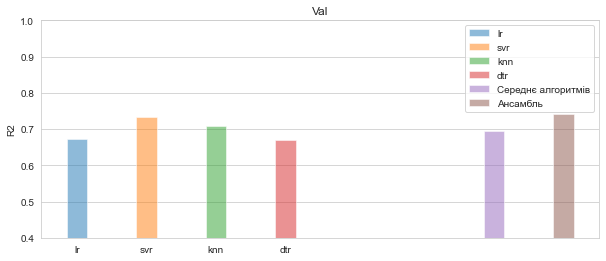

In [34]:
from sklearn.model_selection import KFold
def compare(pipeline):
    global X_train, y_train
    val_est_scores_kf = {est[0]: [] for est in pipeline[1].estimators}
    val_ens_scores_kf = []
    val_est_scores_kf_cv = {est[0]: [] for est in pipeline[1].estimators}
    val_ens_scores_kf_cv = []
    
    kf = KFold(n_splits=5, shuffle=True)
    for _ in range(5):
        for train_idx, val_idx in kf.split(X_train, y_train):
            X_tr, X_val = X_train.reset_index(drop=True).loc[train_idx], X_train.reset_index(drop=True).loc[val_idx]
            y_tr, y_val = y_train.reset_index(drop=True).loc[train_idx], y_train.reset_index(drop=True).loc[val_idx]
            pipeline.fit(X_tr, y_tr)

            # обчислюємо скори для цілого ансамблю
            val_ens_scores_kf.append(pipeline.score(X_val, y_val))

            # обчислюємо скори для окремих алгоритмів
            for est_name in pipeline[1].named_estimators_:
                model = pipeline[1].named_estimators_[est_name]
                inner_pipeline = Pipeline(steps=[
                    ('preprocessing', pipeline[0]),
                    ('regression', model)
                ])
                val_est_scores_kf[est_name].append(inner_pipeline.score(X_val, y_val))

        # усереднюємо скори по всіх фолдах
        # для ансамблю
        val_ens_scores_kf_cv.append(np.mean(val_ens_scores_kf))
        # для окремих алгоритмів
        for est_name in pipeline[1].named_estimators_:
            val_est_scores_kf_cv[est_name].append(np.mean(val_est_scores_kf[est_name]))
    
    # для val
    # середній скор після всіх проходів для окремих алгоритмів        
    print('Val :: скори для окремих алгоритмів: \n  ', {k: np.mean(v) for k, v in val_est_scores_kf_cv.items()})
    # усереднене значення скорів окремих алгоритмів
    print('Val :: середнє скорів окремих алгоритмів: ', np.mean([np.mean(v) for k, v in val_est_scores_kf.items()]))
    # середній скор ансамблю після всіх проходів 
    print('Val :: скор ансамблю : ', np.mean(val_ens_scores_kf_cv), '\n')

    
    # візуалізуємо
    fig = plt.figure(figsize=(10,4))
    #  скори окремих алгоритмів
    for i, (k, v) in enumerate(val_est_scores_kf_cv.items()):
        plt.bar(x=i, height=np.mean(v), align='center', width=0.3, alpha=0.5, label=k)

    # середнє скорів окремих алгоритмів
    plt.bar(
        x=len(pipeline[1].estimators)+2, 
        height=np.mean([np.mean(v) for k, v in val_est_scores_kf.items()]), 
        align='center', width=0.3, alpha=0.5, label="Середнє алгоритмів"
    )
    # скор ансамблю
    plt.bar(
        x=len(pipeline[1].estimators)+3, 
        height=np.mean(val_ens_scores_kf_cv), 
        align='center', width=0.3, alpha=0.5, label="Ансамбль"
    )
    plt.xticks(np.arange(4), val_est_scores_kf.keys())
    plt.title('Val')
    plt.ylabel('R2')
    plt.ylim((0.4,1))
    plt.grid(axis='x')
    plt.legend(loc='best')
    plt.show()
    

compare(pipeline_bin)
get_original()

##### Висновок.

В результаті, на графіку видно, що ансамбль показує незначно кращі результати, ніж найкращі окремі моделі. Найкращим ансамблем виявився `Votingregressor` з скейлингом і бінаризацією на вибраних нами ознаках `lin_selected` з підібраними найкращими параметрами для кожної моделі і ансамблю в цілому та видаленими викидами.

### Bagging Regressor

In [35]:
from sklearn.ensemble import BaggingRegressor
column_transformer = ColumnTransformer([
    ("passthrough", "passthrough", features),
])
pipeline = Pipeline(steps=[
    ('preprocessing', column_transformer),
    ('regression', BaggingRegressor(DecisionTreeRegressor(random_state=4), random_state=5, n_jobs=-1))
]) 
output(pipeline, best_base_params=False)

----------BaggingRegressor(estimator=DecisionTreeRegressor(random_state=4), n_jobs=-1,
                 random_state=5)----------
Test R2: 0.6972
Train R2: 0.9429


Додамо скейлинг, підберемо гіперпараметри для базової моделі і використаємо підібрані нами `lin_selected` ознаки.

In [36]:
from sklearn.ensemble import BaggingRegressor
column_transformer = ColumnTransformer([
    ("scaler", StandardScaler(), lin_selected),
])
pipeline = Pipeline(steps=[
    ('preprocessing', column_transformer),
    ('regression', BaggingRegressor(DecisionTreeRegressor(random_state=4), random_state=5, n_jobs=-1))
]) 
output(pipeline)

----------BaggingRegressor(estimator=DecisionTreeRegressor(max_depth=5, max_features=6,
                                                 min_samples_leaf=20,
                                                 random_state=4),
                 n_jobs=-1, random_state=5)----------
Test R2: 0.7267
Train R2: 0.7443


Бачимо, що результат покращився і зменшилось перенавчання. Спробуємо додати бінаризацію.

In [37]:
pipeline_bin = Pipeline(steps=[
    ('preprocessing', column_transformer_bin),
    ('regression', BaggingRegressor(DecisionTreeRegressor(random_state=4), random_state=5, n_jobs=-1))
]) 
output(pipeline_bin)

----------BaggingRegressor(estimator=DecisionTreeRegressor(criterion='absolute_error',
                                                 min_samples_leaf=20,
                                                 random_state=4),
                 n_jobs=-1, random_state=5)----------
Test R2: 0.7429
Train R2: 0.7407


Бачимо, що результат покращився. Спробуємо також порівняти за допомогою крос-валідації


In [42]:
eval_cv([pipeline, pipeline_bin])

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('scaler', StandardScaler(),
                                                  ['nHM', 'piPC09', 'MLOGP',
                                                   'N-072', 'F04[C-O]', 'ON1V',
                                                   'X2Av'])])),
                ('regression',
                 BaggingRegressor(estimator=DecisionTreeRegressor(max_depth=5,
                                                                  max_features=6,
                                                                  min_samples_leaf=20,
                                                                  random_state=4),
                                  n_jobs=-1, random_state=5))]) -----> 0.6896227959175966
Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('scaler', StandardScaler(),
                                                  ['nHM', 'piPC09', 'MLOGP',
                          

Бачимо, що результати стали дуже подібні, але все ж модель з бінаризацією незначно краща.

Підберемо найкращі параметри тепер для самого ансамблю.

In [43]:
output(pipeline_bin, best_params=True, cv=True)

----------BaggingRegressor(bootstrap=False,
                 estimator=DecisionTreeRegressor(criterion='absolute_error',
                                                 min_samples_leaf=20,
                                                 random_state=4),
                 max_features=0.6000000000000001, n_estimators=8, n_jobs=-1,
                 random_state=5)----------
Test R2: 0.7356
Train R2: 0.7664
CV mean Result: 0.6985307779782316


Бачимо, що на тестовій вибірці результати незначно погрішились, але якщо порівняти за допомогою крос-валідації, то ці параметри будуть найкращими.

Спробуємо також видалити об'єкти, які ми вважаємо викидами

In [44]:
delete = outliers(X, lin_selected, 1)
X.drop(delete, inplace=True)
y.drop(delete, inplace=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=4)
output(pipeline_bin, best_params=True, cv=True)


----------BaggingRegressor(bootstrap=False,
                 estimator=DecisionTreeRegressor(max_depth=5,
                                                 min_samples_leaf=20,
                                                 random_state=4),
                 max_features=0.6000000000000001, n_estimators=14, n_jobs=-1,
                 random_state=5)----------
Test R2: 0.7369
Train R2: 0.7815
CV mean Result: 0.7089748043344488


Бачимо, що це знову позитивно вплинуло на результат

Порівняємо роботу базового алгоритму і ансамблю.

In [45]:
inner_pipeline = Pipeline(steps=[
    ('preprocessing', pipeline_bin[0]),
    ('regression', pipeline_bin[1].estimator)
])

clf_bag_cv = cross_validate(inner_pipeline, X_train, y_train, n_jobs=-1,
                        cv=RepeatedKFold(n_splits=10, n_repeats=10))
bag_cv = cross_validate(pipeline_bin, X_train, y_train, n_jobs=-1,
                                cv=RepeatedKFold(n_splits=10, n_repeats=10))
    
print("Mean for base model: ",clf_bag_cv['test_score'].mean())
print("Mean for bagging: ", bag_cv['test_score'].mean())

Mean for base model:  0.6676658973166674
Mean for bagging:  0.7073907516126944


Бачимо, що як і для попереднього ансамблю, результат ансамблю кращий за результат базової моделі

Подивимось, заради цікавості, на результат ансамблю в залежності від кількості базових моделей.

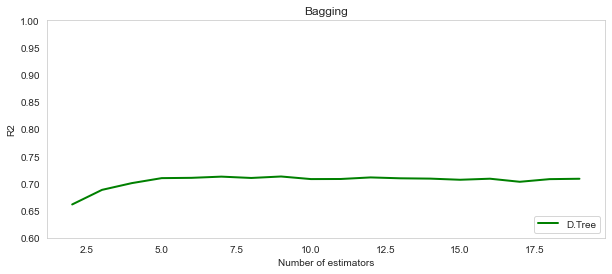

In [46]:
n_est_dict = {}
for n_est in range(2,20): 
    pipeline_bin[1].set_params(n_estimators=n_est)
    bagging_cv = cross_validate(pipeline_bin, X_train, y_train, n_jobs=-1,
                            cv=RepeatedKFold(n_splits=10, n_repeats=10)) 
    n_est_dict[n_est]=bagging_cv['test_score'].mean()

fig = plt.figure(figsize=(10,4))

ne_bag, dtree_bag_scores = n_est_dict.keys(), n_est_dict.values()
plt.plot(ne_bag, dtree_bag_scores, lw=2, color='g', label='D.Tree')

plt.xlabel("Number of estimators")
plt.ylabel("R2")
plt.ylim([0.6,1])
plt.legend(loc = 'lower right')
plt.grid()
plt.title('Bagging')
fig.savefig('bag-est-plot.pdf')
get_original()

##### Висновок.

Отже, найкращим ансамблем, подібно до попереднього, виявився `BaggingRegressor` зі скейлингом і бінаризацією, підібраними оптимальними гіперпараметрами для базової моделі і самого ансамблю, тренований на вибраних ознаках `lin_selected` і з викинутими outliers.

###  AdaBoostRegressor

In [48]:
from sklearn.ensemble import AdaBoostRegressor
column_transformer = ColumnTransformer([
    ("passthrough", "passthrough", features),
])
pipeline = Pipeline(steps=[
    ('preprocessing', column_transformer),
    ('regression', AdaBoostRegressor(DecisionTreeRegressor(random_state=4), random_state=5))
]) 
output(pipeline, best_base_params=False, cv=True) 

----------AdaBoostRegressor(estimator=DecisionTreeRegressor(random_state=4),
                  random_state=5)----------
Test R2: 0.7166
Train R2: 0.9976
CV mean Result: 0.6608239553457387


Бачимо значне перенавчання (що очевидно, враховуючи складність моделі бустингу). Спробуємо зменшити перенавчання, підібравши найкращі параметри для базового алгоритму. Також додамо скейлинг і будемо навчати на вибраних ознаках.

In [49]:
from sklearn.ensemble import AdaBoostRegressor
column_transformer = ColumnTransformer([
    ("scaler", StandardScaler(), lin_selected),
])
pipeline = Pipeline(steps=[
    ('preprocessing', column_transformer),
    ('regression', AdaBoostRegressor(DecisionTreeRegressor(random_state=4), random_state=5))
]) 
output(pipeline, cv=True) 

----------AdaBoostRegressor(estimator=DecisionTreeRegressor(max_depth=5, max_features=6,
                                                  min_samples_leaf=20,
                                                  random_state=4),
                  random_state=5)----------
Test R2: 0.7117
Train R2: 0.8183
CV mean Result: 0.6842566924898651


Бачимо, що перенавчання зникло, а резльтат хоч і погіршився на тестовій вибірці, але крос-валідація показує, що він є кращим.

Спробуємо додати бінаризацію.

In [50]:
pipeline_bin = Pipeline(steps=[
    ('preprocessing', column_transformer_bin),
    ('regression', AdaBoostRegressor(DecisionTreeRegressor(random_state=4), random_state=5))
]) 
output(pipeline_bin, cv=True)

----------AdaBoostRegressor(estimator=DecisionTreeRegressor(criterion='absolute_error',
                                                  min_samples_leaf=20,
                                                  random_state=4),
                  random_state=5)----------
Test R2: 0.7131
Train R2: 0.8661
CV mean Result: 0.6750676804094482


Бачимо, що результати погіршились як на тестовій вибірці, так і при крос-валідації

Заберемо бінаризацію і спробуємо підібрати найкращі гіперпараметри для бустера вцілому.

In [51]:
output(pipeline, best_params=True, cv=True)

----------AdaBoostRegressor(estimator=DecisionTreeRegressor(max_depth=5, max_features=6,
                                                  min_samples_leaf=20,
                                                  random_state=4),
                  learning_rate=0.005179474679231213, loss='exponential',
                  n_estimators=22, random_state=5)----------
Test R2: 0.7327
Train R2: 0.7786
CV mean Result: 0.6892695981973437


Бачимо, що отримали найкращі результати як на тестовій вибірці, так і при крос-валідації

Видалимо об'єкти, які ми вважаємо викидами.

In [52]:
delete = outliers(X, lin_selected, 1)
X.drop(delete, inplace=True)
y.drop(delete, inplace=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=4)
output(pipeline, best_params=True, cv=True)

----------AdaBoostRegressor(estimator=DecisionTreeRegressor(max_depth=5,
                                                  min_samples_leaf=20,
                                                  random_state=4),
                  learning_rate=0.08685113737513529, loss='exponential',
                  n_estimators=22, random_state=5)----------
Test R2: 0.7516
Train R2: 0.7843
CV mean Result: 0.694094410433104


Бачимо, що хоч і результат на тестовій вибірці покращився, але результати на крос-валідації не змінились.
Подивимось на роботу бустера в порівнянні з базовим алгоритмом

In [53]:
inner_pipeline = Pipeline(steps=[
    ('preprocessing', pipeline[0]),
    ('regression', pipeline[1].estimator)
])

clf_boost_cv = cross_validate(inner_pipeline, X_train, y_train, n_jobs=-1,
                        cv=RepeatedKFold(n_splits=10, n_repeats=10))
boost_cv = cross_validate(pipeline, X_train, y_train, n_jobs=-1,
                                cv=RepeatedKFold(n_splits=10, n_repeats=10))
    
print("Mean for base model: ",clf_boost_cv['test_score'].mean())
print("Mean for boost: ", boost_cv['test_score'].mean())

Mean for base model:  0.6647618832939949
Mean for boost:  0.7010632503914251


Як бачимо, результати знову кращі

Подивимось на залежність результату від кількості базових моделей.

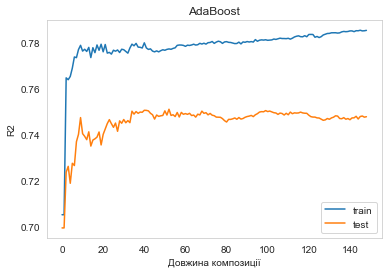

In [54]:
scores_tr = []
scores_ts = []
for n_est in range(1, 150):
    pipeline[1].set_params(n_estimators=n_est)
    pipeline.fit(X_train, y_train)
    scores_tr.append(pipeline.score(X_train, y_train))
    scores_ts.append(pipeline.score(X_test, y_test))
    
plt.plot(scores_tr, label='train')
plt.plot(scores_ts, label='test')
plt.xlabel('Довжина композиції')
plt.ylabel('R2')
plt.title('AdaBoost')
plt.legend()
plt.grid()
get_original()

##### Висновок.

Отже, найкращою моделлю стала `AdaBoostRegressor` з скейлингом і підібраними найкращими параметрами для базовової моделі і бусту вцілому.

###  GradientBoostRegressor

In [60]:
from sklearn.ensemble import GradientBoostingRegressor
column_transformer = ColumnTransformer([
    ("passthrough", "passthrough", features),
])
pipeline = Pipeline(steps=[
    ('preprocessing', column_transformer),
    ('regression', GradientBoostingRegressor())
]) 
output(pipeline, best_base_params=False, cv=True) 

----------GradientBoostingRegressor()----------
Test R2: 0.7339
Train R2: 0.8866
CV mean Result: 0.7064539314882872


Бачимо, що даний буст зразу дає непогані результати, спробуємо додати скейлинг, бінаризацію і перейти на ознаки `lin_selected`. 

In [61]:
from sklearn.ensemble import GradientBoostingRegressor
column_transformer = ColumnTransformer([
    ("scaler", StandardScaler(), features),
])
pipeline = Pipeline(steps=[
    ('preprocessing', column_transformer),
    ('regression', GradientBoostingRegressor())
]) 
output(pipeline, best_base_params=False, cv=True) 

----------GradientBoostingRegressor()----------
Test R2: 0.7341
Train R2: 0.8866
CV mean Result: 0.7045660888648689


In [59]:
column_transformer_bin = ColumnTransformer([
    ("scaler", StandardScaler(), features),
    ('binner', KBinsDiscretizer(n_bins=6, strategy='quantile'), features),
])
pipeline_bin = Pipeline(steps=[
    ('preprocessing', column_transformer_bin),
    ('regression', GradientBoostingRegressor())
]) 
output(pipeline_bin,best_base_params=False, cv=True)

----------GradientBoostingRegressor()----------
Test R2: 0.7329
Train R2: 0.8903
CV mean Result: 0.7070948577642998


Бачимо, що результат майже не  змінився. Спробуємо підібрати оптимальні гіперпараметри і додати `warm_start`.

In [63]:
pipeline_bin[1].set_params(warm_start=True)
output(pipeline_bin, best_base_params=False,best_params=True, cv=True)

----------GradientBoostingRegressor(criterion='squared_error',
                          learning_rate=0.021209508879201904, loss='huber',
                          max_depth=9, max_features='log2', min_samples_leaf=10,
                          n_estimators=280)----------
Test R2: 0.7616
Train R2: 0.9089
CV mean Result: 0.7230918869529467


Бачимо, що результат покращився як на тесті, так і на крос-валідації

Спробуємо задати дерево з оптимальними параметрами, як модель для початкових передбачень в `init`.

In [64]:
inner_pipeline = Pipeline(steps=[
    ('preprocessing', pipeline_bin[0]),
    ('regression', DecisionTreeRegressor(random_state=4))
])
get_best_params(inner_pipeline)
pipeline_bin[1].set_params(init=inner_pipeline[1])
output(pipeline_bin, best_base_params=False, cv=True)

----------GradientBoostingRegressor(criterion='squared_error',
                          init=DecisionTreeRegressor(max_features='log2',
                                                     min_samples_leaf=4,
                                                     random_state=4),
                          learning_rate=0.021209508879201904, loss='huber',
                          max_depth=9, max_features='log2', min_samples_leaf=10,
                          n_estimators=280)----------
Test R2: 0.7001
Train R2: 0.9264
CV mean Result: 0.651639844035508


Бачимо, що результати значно погіршились

Також видалимо об'єкти, які вважаємо викидами.

In [65]:
pipeline_bin[1].set_params(init=None)
delete = outliers(X, lin_selected, 1)
X.drop(delete, inplace=True)
y.drop(delete, inplace=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=4)
output(pipeline_bin, best_base_params=False,best_params=True, cv=True)

----------GradientBoostingRegressor(criterion='squared_error',
                          learning_rate=0.021209508879201904, loss='huber',
                          max_depth=9, max_features='log2', min_samples_leaf=10,
                          n_estimators=280)----------
Test R2: 0.7583
Train R2: 0.9129
CV mean Result: 0.7354358075889471


Результат значно покращився

Спробуємо використати метод ранньої зупинки для підбору оптимальної кількості дерев

In [66]:
from sklearn.metrics import mean_squared_error
pipeline_bin[1].set_params(random_state=20)
pipeline_bin.fit(X_train, y_train)

errors = [mean_squared_error(y_test, y_pred)
          for y_pred in pipeline_bin[1].staged_predict(pipeline_bin[0].transform(X_test))]
bst_n_estimators = np.argmin(errors) + 1

pipeline_bin[1].set_params(n_estimators=bst_n_estimators)
output(pipeline_bin, best_base_params=False, cv=True)
get_original()

----------GradientBoostingRegressor(criterion='squared_error',
                          learning_rate=0.021209508879201904, loss='huber',
                          max_depth=9, max_features='log2', min_samples_leaf=10,
                          n_estimators=232, random_state=20)----------
Test R2: 0.7549
Train R2: 0.9015
CV mean Result: 0.7353510884939706


Бачимо, що результат і кількість дерев майже не змінились, що означає, що підбір методом крос-валідації не програє підбору даним методом.

##### Висновок.

Загалом найкращою моделлю стала `GradientBoostingRegressor` зі скейлингом, бінаризацією, підбором найкращих параметрів, навчена на всіх ознаках з видаленими outliers.

###  XGBRegressor

In [69]:
import xgboost
column_transformer = ColumnTransformer([
    ("passthrough", "passthrough", features),
])
pipeline = Pipeline(steps=[
    ('preprocessing', column_transformer),
    ('regression', xgboost.XGBRegressor())
]) 
output(pipeline, best_base_params=False, cv=True) 

----------XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=None, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=None, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=None, n_jobs=None,
             num_parallel_tree=None, random_state=None, ...)----------
Test R2: 0.7417
Train R2: 0.9983
CV mean Result: 0.6679857143800919


Додамо скейлинг і поексперементуємо з бінаризацією

In [68]:
import xgboost
pipeline_bin = Pipeline(steps=[
    ('preprocessing', column_transformer_bin),
    ('regression', xgboost.XGBRegressor(n_jobs=-1))
]) 
output(pipeline_bin, best_base_params=False, cv=True) 

----------XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=None, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=None, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=None, n_jobs=-1,
             num_parallel_tree=None, random_state=None, ...)----------
Test R2: 0.7088
Train R2: 0.9983
CV mean Result: 0.6733466712531561


Бачимо, що це майже не змінює результати. Спробуємо підібрати оптимальні гіперпараметри для бусту.

In [71]:
output(pipeline_bin, best_base_params=False,best_params=True, cv=True) 

----------XGBRegressor(base_score=None, booster='gbtree', callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.31622776601683794,
             max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=5, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=60, n_jobs=-1,
             num_parallel_tree=None, random_state=None, ...)----------
Test R2: 0.7106
Train R2: 0.9038
CV mean Result: 0.7114275388455088


Результати покращились і зменшилось перенавчання

Видалимо outliers і подивимось на результат

In [72]:
delete = outliers(X, features, 1)
X.drop(delete, inplace=True)
y.drop(delete, inplace=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=4)
output(pipeline_bin, best_base_params=False,best_params=True, cv=True)

----------XGBRegressor(base_score=None, booster='dart', callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.046415888336127795,
             max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=None, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=300, n_jobs=-1,
             num_parallel_tree=None, random_state=None, ...)----------
Test R2: 0.7646
Train R2: 0.9244
CV mean Result: 0.7177092132496021


Бачимо, що результат знову покращився.

Поексперементуємо з параметром `booster`

In [73]:
pipeline_bin[1].set_params(booster="gbtree")
output(pipeline_bin, best_base_params=False,best_params=False, cv=True)

----------XGBRegressor(base_score=None, booster='gbtree', callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.046415888336127795,
             max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=None, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=300, n_jobs=-1,
             num_parallel_tree=None, random_state=None, ...)----------
Test R2: 0.7646
Train R2: 0.9244
CV mean Result: 0.718587568877652


Бачимо, що зміна з `dart` на `gbtree` не змінила результат. Спробуємо `gblinear`

In [74]:
pipeline[1].set_params(booster="gblinear")
output(pipeline, best_base_params=False,best_params=False, cv=True)

----------XGBRegressor(base_score=None, booster='gblinear', callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=None, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=None, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=None, n_jobs=None,
             num_parallel_tree=None, random_state=None, ...)----------
Test R2: 0.6951
Train R2: 0.686
CV mean Result: 0.6577384782548066


Бачимо, що такий бустер показує себе значно гірше.

Використаємо `xgboost` і підібрані параметри для визначення важливості ознак

In [75]:
data_dmatrix = xgboost.DMatrix(data=X_train.rename(columns={"B02[C-N]": "B02(C-N)", "F04[C-O]": "F04(C-O)"}),label=y_train)

In [76]:
xg_reg = xgboost.train(params=pipeline_bin[1].get_params(), dtrain=data_dmatrix, num_boost_round=10)

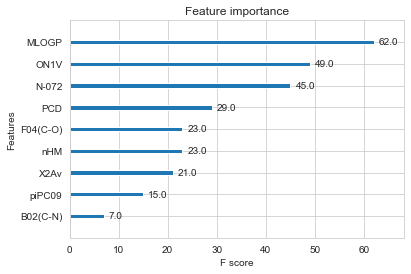

In [77]:
xgboost.plot_importance(xg_reg)
plt.rcParams['figure.figsize'] = [5, 5]
plt.show()
get_original()

Цікаво, що перші ознаки співпадають з підібраними нами за допомогою `SequentialFeatureSelector`

##### Висновок.

Отже, найкращою виявилась модель `XGBRegressor` з скейлингом, бінаризацією, підбором гіперпараметрів на всіх ознаках з видаленими outliers.

###  StackingRegressor

In [79]:
from sklearn.ensemble import StackingRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import RidgeCV
column_transformer = ColumnTransformer([
    ("passthrough", "passthrough", features),
])
pipeline = Pipeline(steps=[
    ('preprocessing', column_transformer),
    ('regression', StackingRegressor([("lr",LinearRegression()), ("svr", SVR()), ("knn", KNeighborsRegressor()), ("dtr", DecisionTreeRegressor(random_state=4))], n_jobs=-1, final_estimator=RidgeCV()))
]) 
output(pipeline, best_base_params=False, cv=True) 


----------StackingRegressor(estimators=[('lr', LinearRegression()), ('svr', SVR()),
                              ('knn', KNeighborsRegressor()),
                              ('dtr', DecisionTreeRegressor(random_state=4))],
                  final_estimator=RidgeCV(), n_jobs=-1)----------
Test R2: 0.6972
Train R2: 0.8089
CV mean Result: 0.7088626927585725


Бачимо, що початкові результати є непоганими. Додамо скейлинг і поексперементуємо з бінаризацією. Також подивимось на результати на вибраних ознаках `lin_selected`

In [80]:
from sklearn.ensemble import StackingRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import RidgeCV
column_transformer_bin = ColumnTransformer([
    ("scaler", StandardScaler(), lin_selected),
    ('binner', KBinsDiscretizer(n_bins=6, strategy='quantile'), lin_selected),
])
pipeline_bin = Pipeline(steps=[
    ('preprocessing', column_transformer_bin),
    ('regression', StackingRegressor([("lr",LinearRegression()), ("svr", SVR()), ("knn", KNeighborsRegressor()), ("dtr", DecisionTreeRegressor(random_state=4))], n_jobs=-1, final_estimator=RidgeCV()))
]) 
output(pipeline_bin, best_base_params=False, cv=True) 


----------StackingRegressor(estimators=[('lr', LinearRegression()), ('svr', SVR()),
                              ('knn', KNeighborsRegressor()),
                              ('dtr', DecisionTreeRegressor(random_state=4))],
                  final_estimator=RidgeCV(), n_jobs=-1)----------
Test R2: 0.7221
Train R2: 0.8608
CV mean Result: 0.7262980527596911


Бачимо покращення результатів на крос-валідації. Спробуємо підібрати найкращі параметри для базових моделей.

In [81]:
output(pipeline_bin, cv=True) 

----------StackingRegressor(estimators=[('lr', LinearRegression()),
                              ('svr', SVR(C=0.825404185268019)),
                              ('knn',
                               KNeighborsRegressor(n_neighbors=8,
                                                   weights='distance')),
                              ('dtr',
                               DecisionTreeRegressor(criterion='absolute_error',
                                                     min_samples_leaf=20,
                                                     random_state=4))],
                  final_estimator=RidgeCV(), n_jobs=-1)----------
Test R2: 0.7478
Train R2: 0.9184
CV mean Result: 0.732294223444208


Це ще більше покращило результат. Спробуємо також поексперементувати з параметрами `RidgeCV`

In [82]:
pipeline_bin[1].final_estimator.set_params(alphas=np.logspace(-2,3,200), gcv_mode="svd")
output(pipeline_bin,best_base_params=False, cv=True) 

----------StackingRegressor(estimators=[('lr', LinearRegression()),
                              ('svr', SVR(C=0.825404185268019)),
                              ('knn',
                               KNeighborsRegressor(n_neighbors=8,
                                                   weights='distance')),
                              ('dtr',
                               DecisionTreeRegressor(criterion='absolute_error',
                                                     min_samples_leaf=20,
                                                     random_state=4))],
                  final_estimator=RidgeCV(alphas=array([1.00000000e-02, 1.05956018e-02, 1.12266777e-02, 1.18953407e-02,
       1.26038...
       2.64308149e+02, 2.80050389e+02, 2.96730241e+02, 3.14403547e+02,
       3.33129479e+02, 3.52970730e+02, 3.73993730e+02, 3.96268864e+02,
       4.19870708e+02, 4.44878283e+02, 4.71375313e+02, 4.99450512e+02,
       5.29197874e+02, 5.60716994e+02, 5.94113398e+02, 6.29498899e+02,
   

Бачимо, що на результати це майже не вплинуло. Викинемо `outliers`.

In [83]:
pipeline_bin[1].final_estimator.set_params(alphas=(0.1,1,10), gcv_mode="auto")
delete = outliers(X, lin_selected, 1)
X.drop(delete, inplace=True)
y.drop(delete, inplace=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=4)
output(pipeline_bin, cv=True)

----------StackingRegressor(estimators=[('lr', LinearRegression()),
                              ('svr', SVR(C=0.825404185268019)),
                              ('knn',
                               KNeighborsRegressor(n_neighbors=6,
                                                   weights='distance')),
                              ('dtr',
                               DecisionTreeRegressor(max_depth=5,
                                                     min_samples_leaf=20,
                                                     random_state=4))],
                  final_estimator=RidgeCV(alphas=(0.1, 1, 10), gcv_mode='auto'),
                  n_jobs=-1)----------
Test R2: 0.7686
Train R2: 0.9332
CV mean Result: 0.7367682169965147


Бачимо, що це позитивно вплинуло на результати. Спробуємо також `passthrough = True`

In [87]:
pipeline_bin[1].final_estimator.set_params(alphas=np.logspace(-2,3,200))
pipeline_bin[1].set_params(passthrough=True)
output(pipeline_bin, cv=True)

----------StackingRegressor(estimators=[('lr', LinearRegression()),
                              ('svr', SVR(C=0.825404185268019)),
                              ('knn',
                               KNeighborsRegressor(n_neighbors=6,
                                                   weights='distance')),
                              ('dtr',
                               DecisionTreeRegressor(max_depth=5,
                                                     min_samples_leaf=20,
                                                     random_state=4))],
                  final_estimator=RidgeCV(alphas=array([1.00000000e-02, 1.05956018e-02, 1.12266777e-02, 1.18953407e-02,
       1.26038293e-02, 1.33545...
       2.64308149e+02, 2.80050389e+02, 2.96730241e+02, 3.14403547e+02,
       3.33129479e+02, 3.52970730e+02, 3.73993730e+02, 3.96268864e+02,
       4.19870708e+02, 4.44878283e+02, 4.71375313e+02, 4.99450512e+02,
       5.29197874e+02, 5.60716994e+02, 5.94113398e+02, 6.29498899e+02,
  

Бачимо, що це погіршило результати. Спробуємо тепер `RandomForestRegressor` як фінальну модель.

In [88]:
pipeline_bin[1].set_params(passthrough=False, final_estimator=RandomForestRegressor(n_jobs=-1))
output(pipeline_bin, cv=True)

----------StackingRegressor(estimators=[('lr', LinearRegression()),
                              ('svr', SVR(C=0.825404185268019)),
                              ('knn',
                               KNeighborsRegressor(n_neighbors=6,
                                                   weights='distance')),
                              ('dtr',
                               DecisionTreeRegressor(max_depth=5,
                                                     min_samples_leaf=20,
                                                     random_state=4))],
                  final_estimator=RandomForestRegressor(n_jobs=-1), n_jobs=-1)----------
Test R2: 0.7471
Train R2: 0.8881
CV mean Result: 0.7035851883175697


Бачимо, що результати гірші, але спробуємо підібрати параметри для фінальної моделі.

In [89]:
output(pipeline_bin, best_params=True, cv=True)

----------StackingRegressor(estimators=[('lr', LinearRegression()),
                              ('svr', SVR(C=0.825404185268019)),
                              ('knn',
                               KNeighborsRegressor(n_neighbors=6,
                                                   weights='distance')),
                              ('dtr',
                               DecisionTreeRegressor(max_depth=5,
                                                     min_samples_leaf=20,
                                                     random_state=4))],
                  final_estimator=RandomForestRegressor(criterion='absolute_error',
                                                        max_depth=5,
                                                        max_features='log2',
                                                        min_samples_leaf=4,
                                                        n_estimators=190,
                                                        n_jo

Загалом результати на рівні з `RidgeCV`. Порівняємо результати базових моделей і ансамблю.

Val :: скори для окремих алгоритмів: 
   {'lr': 0.6457866935946133, 'svr': 0.7293726983195887, 'knn': 0.6948461591427103, 'dtr': 0.6749837457920835}
Val :: середнє скорів окремих алгоритмів:  0.6862948641485812
Val :: скор ансамблю :  0.727091651048475 



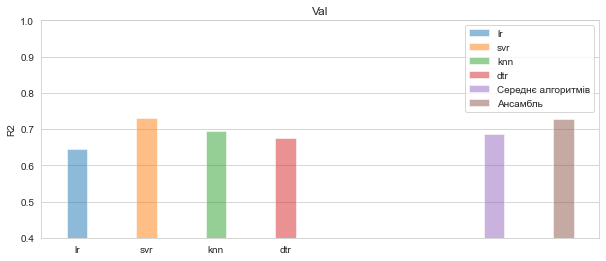

In [91]:
compare(pipeline_bin)

Бачимо, що результати ансамблю є на рівні з найкращою базовою моделлю і приблизно на рівні з `VotingRegressor`

##### Висновок.

Найкращою моделлю була `StackingRegressor` з скейлингом, бінаризацією, підібраними параметрами для базових алгоритмів і фінальною моделлю `RidgeCV` з викинутими outliers.

### Зробити висновки і обрати найкращу модель яка розв'язує задачу регресії. Для найкращої моделі знайти прогнози на вибірці `bio_predict.csv`. Значення прогнозів зберегти у файл `predictions_reg.csv`.



Загалом всі використані моделі показували себе на подібному рівні. Цікаво, що більшість з них мали кращі результати на ознаках `lin selected` i з викинутими `outliers`. Найкращими за результатами на крос-валідації були моделі `GradientBoostRegressor` i `StackingRegressor`. Зробимо фінальні прогнози.

In [93]:
predict = pd.read_csv("bio_predict.csv")

In [97]:
column_transformer_bin = ColumnTransformer([
    ("scaler", StandardScaler(), features),
    ('binner', KBinsDiscretizer(n_bins=6, strategy='quantile'), features),
])
pipeline_bin = Pipeline(steps=[
    ('preprocessing', column_transformer_bin),
    ('regression', GradientBoostingRegressor())
]) 

pipeline_bin[1].set_params(criterion='squared_error',
                          learning_rate=0.021209508879201904, loss='huber',
                          max_depth=9, max_features='log2', min_samples_leaf=10,
                          n_estimators=280,random_state=5)
delete = outliers(X, features, 1)
X.drop(delete, inplace=True)
y.drop(delete, inplace=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=60)
pipeline_bin.fit(X_train, y_train)
y_final = pipeline_bin.predict(predict)
output(pipeline_bin, best_base_params=False)

----------GradientBoostingRegressor(criterion='squared_error',
                          learning_rate=0.021209508879201904, loss='huber',
                          max_depth=9, max_features='log2', min_samples_leaf=10,
                          n_estimators=280, random_state=5)----------
Test R2: 0.7606
Train R2: 0.9148


In [98]:
# Зберегти прогнози у змінну best_reg_model_predictions
best_reg_model_predictions = y_final 

In [99]:
# Запустити для створення файлу
pd.Series(best_reg_model_predictions).to_csv('predictions_reg.csv')